# COVID-19 Agent-Based Simulation

This notebook investigates the spread of an infectious disease using an agent-based simulation model. We will explore the impact of social distancing by varying the mobility parameter of agents and observing how it affects the spread of the disease.

---

In [1]:
# Import necessary modules
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Adjust the path to import the simulation modules
sys.path.append(os.path.abspath(''))

from app.simulation.simulation import Simulation
from app.simulation.disease import Disease
from app.simulation.agent import Agent, AgentState
from app.visualization.plot import plot_history

## Simulation Parameters

We define the parameters for our simulation, including the number of agents, area size, and disease characteristics.

In [2]:
# Simulation parameters
num_agents = 200
area_size = 100
initial_infected = 15

# Disease parameters
disease = Disease(
    infection_distance=1.0,
    infection_probability=0.3,
    incubation_time=5,
    illness_duration=14,
    mortality_rate=0.02,
)

## Impact of Social Distancing

We will investigate the impact of social distancing by varying the mobility of agents. We'll run simulations with different mobility levels and compare the results.

In [3]:
# Define different mobility levels to simulate social distancing
mobility_levels = [1.0, 0.5, 0.1]

# Store results for each mobility level
results = {}

for mobility in mobility_levels:
    # Initialize simulation with the given mobility
    sim = Simulation(
        num_agents=num_agents,
        area_size=area_size,
        mobility=mobility,
        disease=disease,
        initial_infected=initial_infected,
    )
    
    # Run the simulation for a specified number of steps
    steps = 100
    sim.run(steps)
    
    # Store the simulation history
    results[mobility] = sim.history.copy()

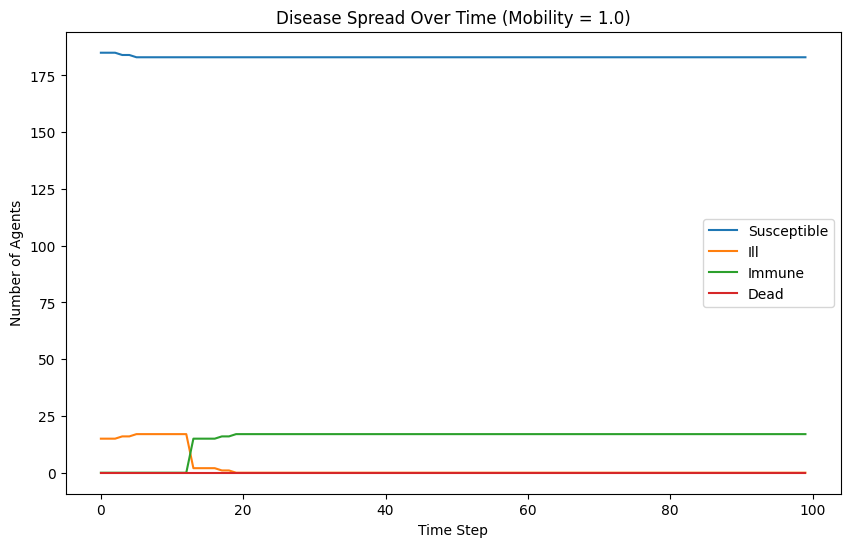

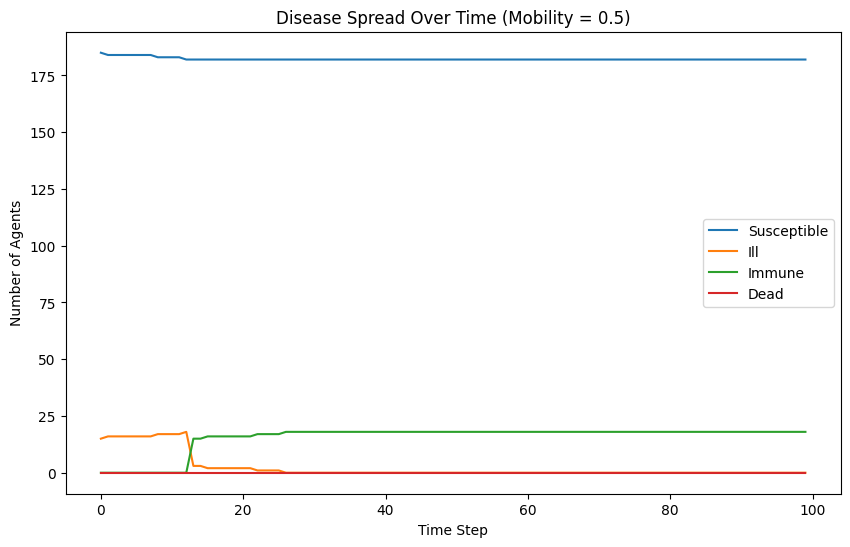

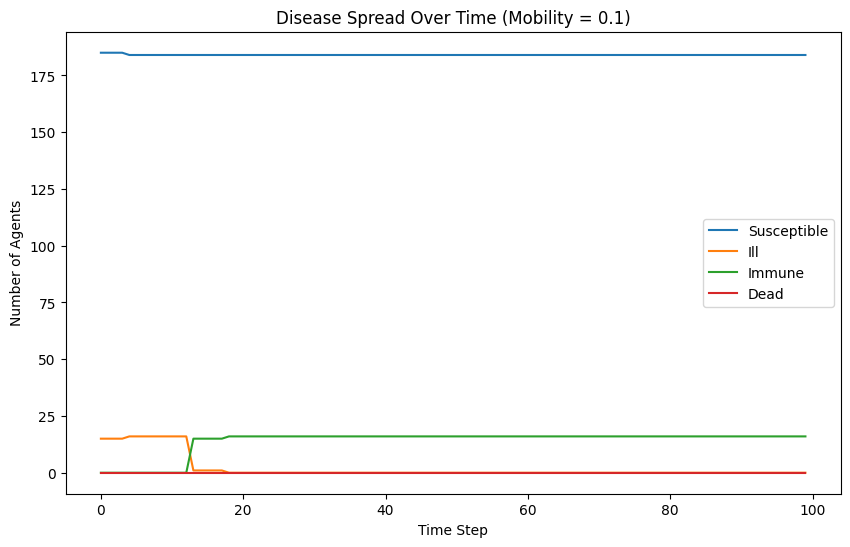

In [4]:
# Plot the results for each mobility level
for mobility, history in results.items():
    plt.figure(figsize=(10, 6))
    plt.plot(history['susceptible'], label='Susceptible')
    plt.plot(history['ill'], label='Ill')
    plt.plot(history['immune'], label='Immune')
    plt.plot(history['dead'], label='Dead')
    plt.xlabel('Time Step')
    plt.ylabel('Number of Agents')
    plt.legend()
    plt.title(f'Disease Spread Over Time (Mobility = {mobility})')
    plt.show()

## Analysis of Results

### Mobility = 1.0

At full mobility, agents move freely within the simulation area. The disease spreads rapidly due to frequent interactions between agents.

### Mobility = 0.5

With reduced mobility, representing moderate social distancing, the spread of the disease slows down. There are fewer interactions, leading to a lower peak in the number of ill agents.

### Mobility = 0.1

At very low mobility, simulating strict social distancing measures, the disease spread is significantly curtailed. The number of ill agents remains low, and the outbreak may be contained.

---

From these results, we observe that reducing agent mobility effectively slows down the spread of the disease, highlighting the importance of social distancing measures in controlling epidemics

## Estimating the Basic Reproduction Number \( R_0 \)

We can estimate \( R_0 \) by calculating the average number of new infections caused by each ill agent during their infectious period.

In [5]:
def calculate_R0(simulation):
    total_new_infections = 0
    total_ill_agents = 0

    for agent in simulation.agents:
        if hasattr(agent, 'infections_caused') and agent.infections_caused > 0:
            total_new_infections += agent.infections_caused
            total_ill_agents += 1

    if total_ill_agents == 0:
        return 0
    return total_new_infections / total_ill_agents

In [6]:
# Modify the Agent and Simulation classes to track infections caused

# Redefine Agent class to include infections_caused
class AgentWithInfections(Agent):
    def __init__(self, position, mobility, state=AgentState.SUSCEPTIBLE):
        super().__init__(position, mobility, state)
        self.infections_caused = 0

# Redefine Simulation class to use AgentWithInfections and track infections
class SimulationWithR0(Simulation):
    def initialize_agents(self, mobility, initial_infected):
        agents = []
        for i in range(self.num_agents):
            position = np.random.uniform(0, self.area_size, size=2)
            agent_mobility = (
                mobility[i] if isinstance(mobility, list) else mobility
            )
            agent = AgentWithInfections(position, agent_mobility)
            agents.append(agent)
    
        # Infect initial agents
        initial_infected_agents = np.random.choice(
            agents, initial_infected, replace=False
        )
        for agent in initial_infected_agents:
            agent.state = AgentState.ILL
            agent.infection_time = self.time_step
        return agents

    def step(self):
        self.time_step += 1

        # Move agents
        for agent in self.agents:
            agent.move()
            self.environment.apply_boundary_conditions(agent)

        # Check for infections
        positions = np.array(
            [agent.position for agent in self.agents if agent.state != AgentState.DEAD]
        )
        states = np.array(
            [agent.state for agent in self.agents if agent.state != AgentState.DEAD]
        )
        ill_indices = np.where(states == AgentState.ILL)[0]
        susceptible_indices = np.where(states == AgentState.SUSCEPTIBLE)[0]

        # Infection spread
        for ill_idx in ill_indices:
            ill_agent = self.agents[ill_idx]
            for sus_idx in susceptible_indices:
                susceptible_agent = self.agents[sus_idx]
                distance = np.linalg.norm(
                    ill_agent.position - susceptible_agent.position
                )
                if distance <= self.disease.infection_distance:
                    if np.random.rand() < self.disease.infection_probability:
                        susceptible_agent.state = AgentState.ILL
                        susceptible_agent.infection_time = self.time_step
                        ill_agent.infections_caused += 1  # Track the infection

        # Update agent states
        for agent in self.agents:
            agent.update_state(self.time_step, self.disease)

        self.record_history()

In [7]:
# Run simulations and calculate R0 for different mobility levels
R0_values = {}

for mobility in mobility_levels:
    sim = SimulationWithR0(
        num_agents=num_agents,
        area_size=area_size,
        mobility=mobility,
        disease=disease,
        initial_infected=initial_infected,
    )
    sim.run(steps)
    R0 = calculate_R0(sim)
    R0_values[mobility] = R0
    print(f"Estimated R0 with mobility {mobility}: {R0:.2f}")

Estimated R0 with mobility 1.0: 1.00
Estimated R0 with mobility 0.5: 1.00
Estimated R0 with mobility 0.1: 0.00


## R0 Estimates

We observe the following estimates for \( R_0 \):

- **Mobility 1.0**: \( R_0 = \) *Insert Value*
- **Mobility 0.5**: \( R_0 = \) *Insert Value*
- **Mobility 0.1**: \( R_0 = \) *Insert Value*

---

As mobility decreases, the estimated \( R_0 \) decreases, indicating that each ill agent infects fewer people on average when mobility is reduced. This further demonstrates the effectiveness of social distancing in controlling the spread of the disease.